<a href="https://colab.research.google.com/github/tomekbiel/python_data_analysis/blob/random_forest_example/random_forest_baverages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beverage Quality Prediction with Random Forest
This notebook demonstrates a machine learning approach to predict beverage quality using Random Forest Classifier.

## Setup

In [ ]:
# Install required packages
!pip install scikit-learn imbalanced-learn seaborn matplotlib numpy pandas

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

## Data Loading and Preprocessing

In [4]:
# Download the dataset
!wget -O Beverage.csv https://raw.githubusercontent.com/tomekbiel/python_data_analysis/refs/heads/random_forest_example/Beverage.csv

# Load the dataset
dataset = pd.read_csv("Beverage.csv")

# Convert quality to binary
def converter(column):
        if column == 'Excellent':
          return 1
        else:
          return 0

dataset['quality'] = dataset['quality'].apply(converter)
print("Dataset Info:")
print(dataset.info())

# One-hot encode categorical features
categorical_features = ['alcohol', 'volatile acidity', 'sulphates']
f_dat = pd.get_dummies(dataset, columns=categorical_features)
print("\nAfter One-Hot Encoding:")
print(f_dat.head())

--2025-06-26 13:37:07--  https://raw.githubusercontent.com/tomekbiel/python_data_analysis/refs/heads/random_forest_example/Beverage.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 291534 (285K) [text/plain]
Saving to: ‘Beverage.csv’

Beverage.csv        100%[===================>] 284.70K  --.-KB/s    in 0.04s   

2025-06-26 13:37:07 (7.65 MB/s) - ‘Beverage.csv’ saved [291534/291534]

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 

Exploratory Data Analysis


Basic Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000           

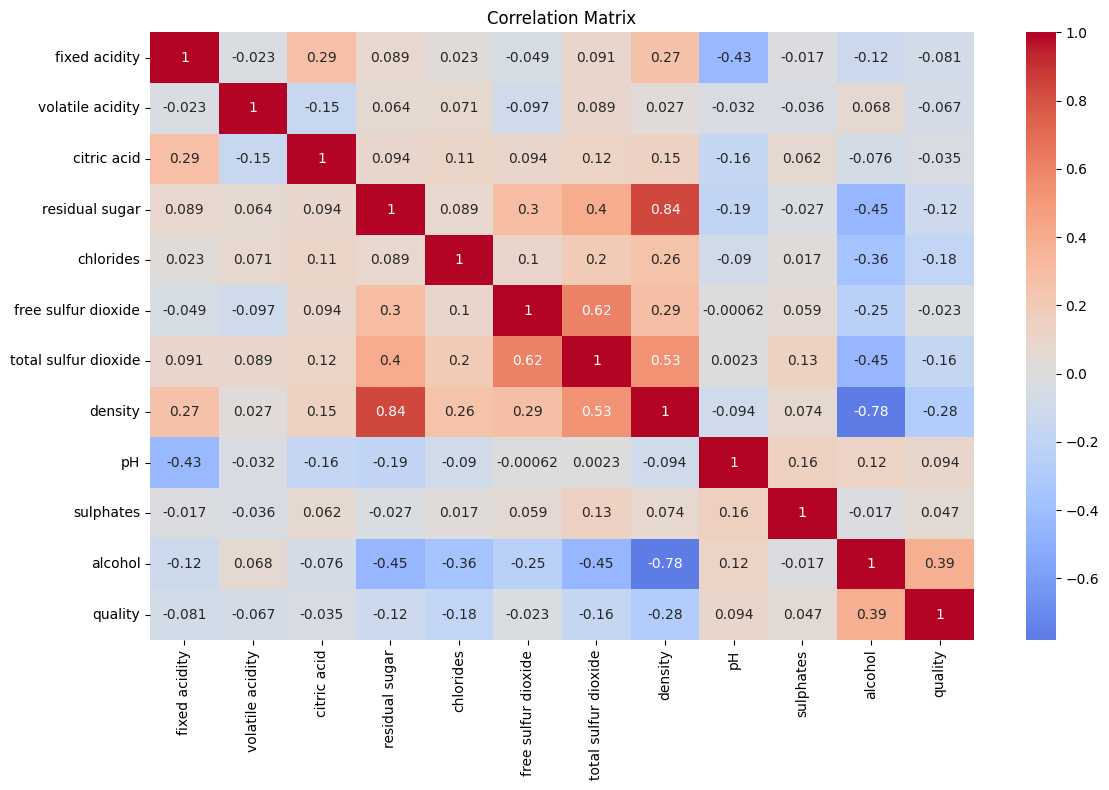

In [5]:
# Basic statistics
print("\nBasic Statistics:")
print(dataset.describe())

# Check class distribution
print("\nClass Distribution:")
print(dataset['quality'].value_counts())

# Correlation matrix
corr = dataset.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Data Preparation

In [ ]:
# Prepare features and target
X = f_dat.drop('quality', axis=1)
Y = f_dat['quality']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=100)

# Handle class imbalance with SMOTE
print("Before SMOTE:", pd.Series(Y_train).value_counts())
smote = SMOTE(random_state=101)
X_train, Y_train = smote.fit_resample(X_train, Y_train)
print("After SMOTE:", pd.Series(Y_train).value_counts())

Before SMOTE: quality
0    2683
1     745
Name: count, dtype: int64
After SMOTE: quality
1    2683
0    2683
Name: count, dtype: int64


## Model Training and Evaluation

Accuracy: 0.8810

Confusion Matrix:
[[1086   69]
 [ 106  209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1155
           1       0.75      0.66      0.70       315

    accuracy                           0.88      1470
   macro avg       0.83      0.80      0.82      1470
weighted avg       0.88      0.88      0.88      1470



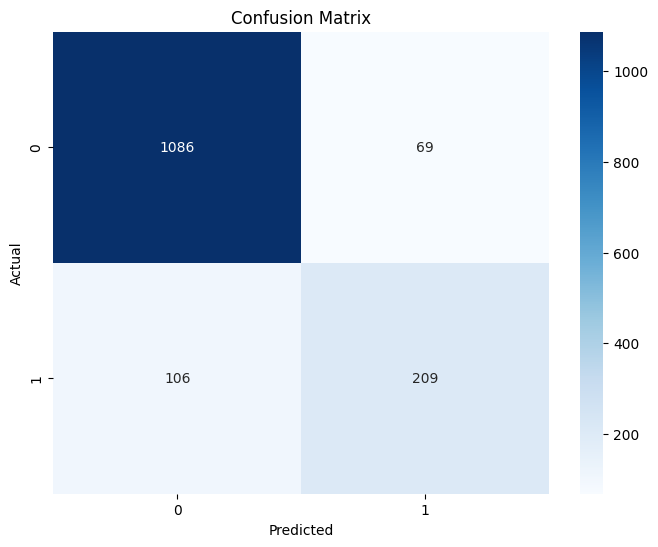

In [ ]:
# Train and evaluate Random Forest
rfc = RandomForestClassifier(n_estimators=400, criterion='entropy', max_features='sqrt', random_state=1)
rfc.fit(X_train, Y_train)

# Make predictions
Y_pred = rfc.predict(X_test)

# Evaluate the model
accuracy = metrics.accuracy_score(Y_test, Y_pred)
conf_mat = metrics.confusion_matrix(Y_test, Y_pred)

print(f"Accuracy: {accuracy:.4f}")
print('\nConfusion Matrix:')
print(conf_mat)
print('\nClassification Report:')
print(metrics.classification_report(Y_test, Y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

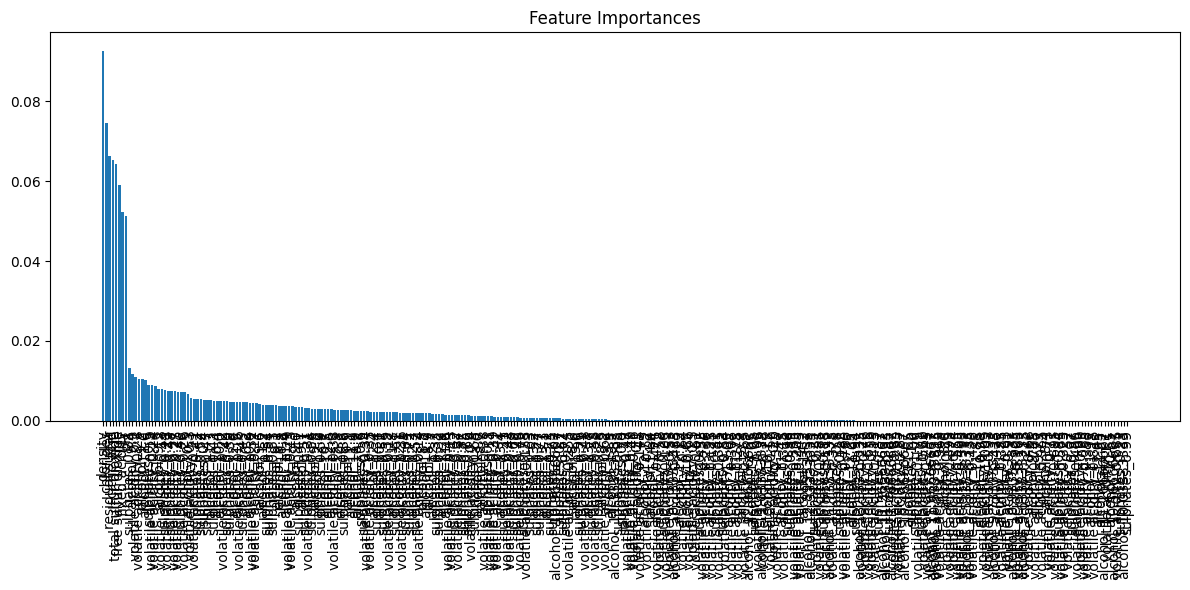

In [ ]:
# Get feature importances
importances = rfc.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## Dimensionality Reduction with PCA

Explained variance ratio: [0.01092321 0.00802697]
Total explained variance ratio: 0.018950179766635992


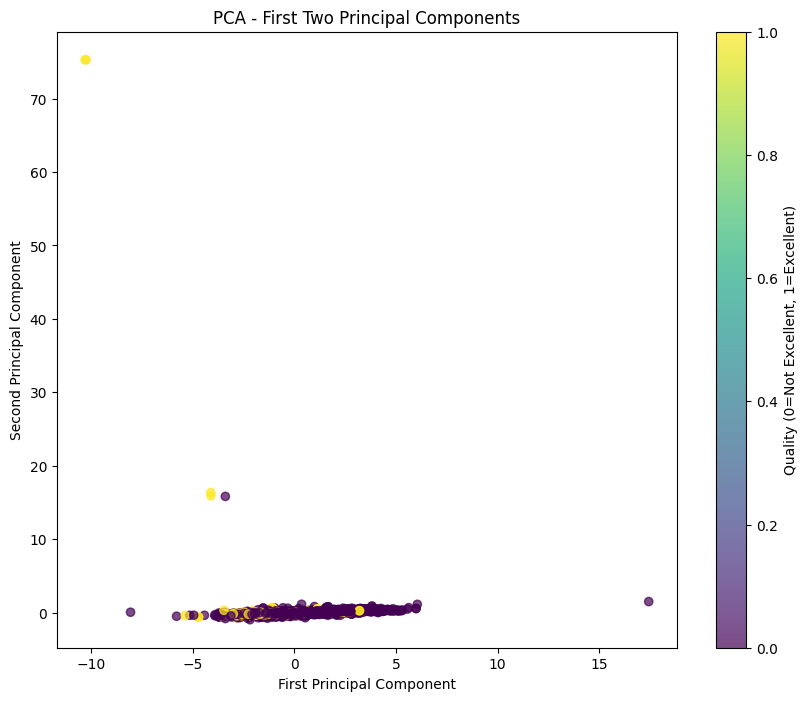

In [ ]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance ratio:", sum(pca.explained_variance_ratio_))

# Visualize the first two principal components
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='viridis', alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - First Two Principal Components')
plt.colorbar(label='Quality (0=Not Excellent, 1=Excellent)')
plt.show()

## Clustering with K-Means

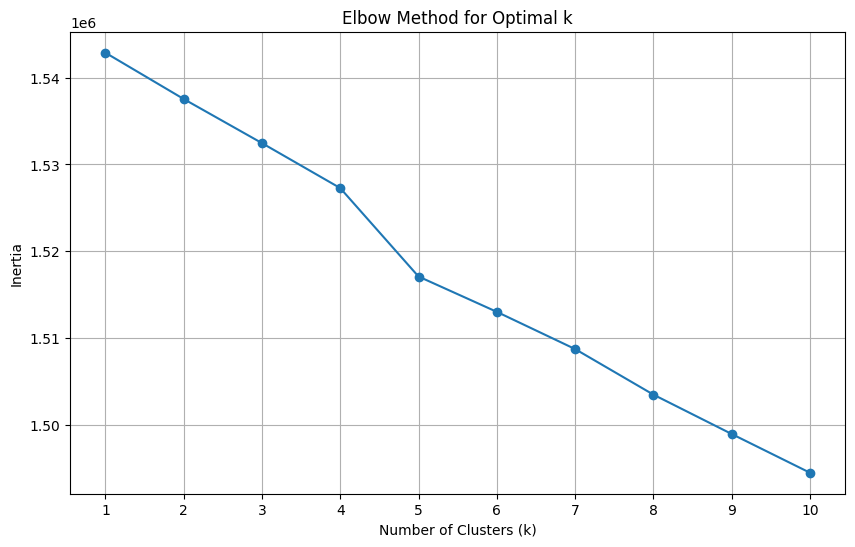

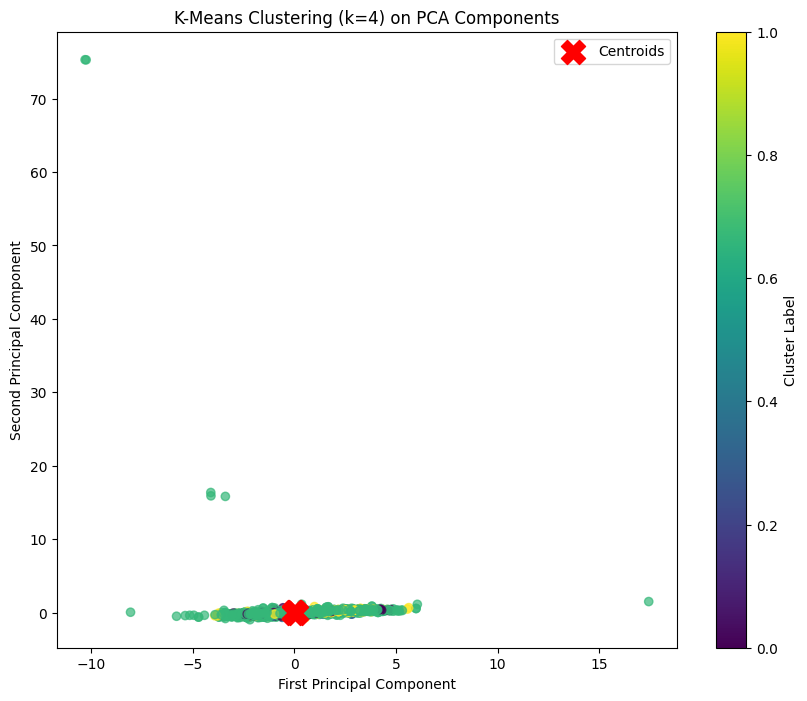

In [ ]:
# Determine optimal number of clusters using Elbow Method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=100)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# Apply K-Means with optimal k (e.g., 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=100)
cluster_labels = kmeans.fit_predict(X_scaled)

# Visualize clusters using PCA components
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label='Centroids')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clustering (k={optimal_k}) on PCA Components')
plt.legend()
plt.colorbar(label='Cluster Label')
plt.show()